In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [54]:
# Select all columns starting from the third column (index 2) to preprocess the data
df = df.iloc[:,2:]

In [55]:
df.sample(5)

,Age,EstimatedSalary,Purchased
329,47,107000,1
302,37,137000,1
261,36,144000,1
305,42,54000,0
57,28,79000,0


# Train test Split

In [56]:
# Import the train_test_split function for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# X contains features (all columns except 'Purchased'), y contains the target variable ('Purchased')
# test_size=0.3 means 30% of the data will be used for testing
# random_state=0 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis = 1),
                                                    df['Purchased'],
                                                    test_size = 0.3,
                                                    random_state = 0)

# Print the shapes of the training and testing feature sets
# This shows the number of rows and columns in X_train and X_test
X_train.shape, X_test.shape

((280, 2), (120, 2))

# StandardScaler

In [57]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data
# This step learns the mean and standard deviation from the training data
scaler.fit(X_train)

# Transform both the training and testing data using the learned parameters
# This scales the features to have a mean of 0 and a standard deviation of 1
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
# Display the mean values learned by the scaler for each feature
# These are used to center the data during scaling
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [59]:
# Convert the scaled NumPy arrays back into pandas DataFrames
# Assign original column names for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [60]:
# Display descriptive statistics (mean, std, min, max, etc.) for the scaled training data
# np.round(..., 1) rounds the output to 1 decimal place
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In [61]:
# Display descriptive statistics for the original (unscaled) training data
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


# Effect of scaling

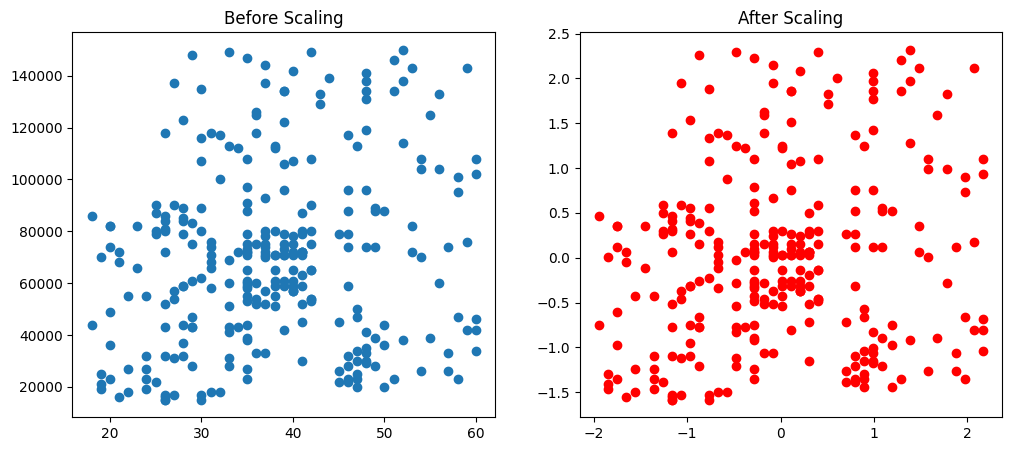

In [62]:
# Create a figure with two subplots side-by-side
# ncols=2 means two columns of subplots, figsize sets the overall size of the figure
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Scatter plot of 'Age' vs 'EstimatedSalary' for the original training data
# Shows the distribution of data before scaling
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling") # Set title for the first subplot

# Scatter plot of 'Age' vs 'EstimatedSalary' for the scaled training data
# Shows how scaling changes the distribution of data, typically bringing it closer to the origin
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color = 'red') # Use red color for scaled data points
ax2.set_title("After Scaling") # Set title for the second subplot
plt.show() # Display the plot

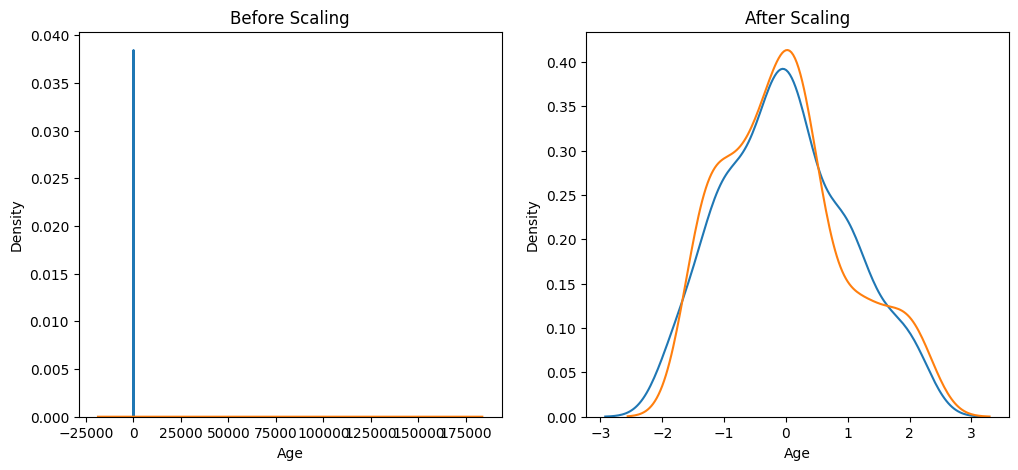

In [63]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Plot kernel density estimates (KDE) for 'Age' and 'EstimatedSalary' before scaling
# KDE plots show the probability density of the data
ax1.set_title("Before Scaling") # Set title for the first subplot
sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

# Plot kernel density estimates (KDE) for 'Age' and 'EstimatedSalary' after scaling
# Observe how scaling transforms the distribution, making features comparable
ax2.set_title("After Scaling") # Set title for the second subplot
sns.kdeplot(X_train_scaled['Age'], ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)
plt.show() # Display the plot

# Comparison of Distributions

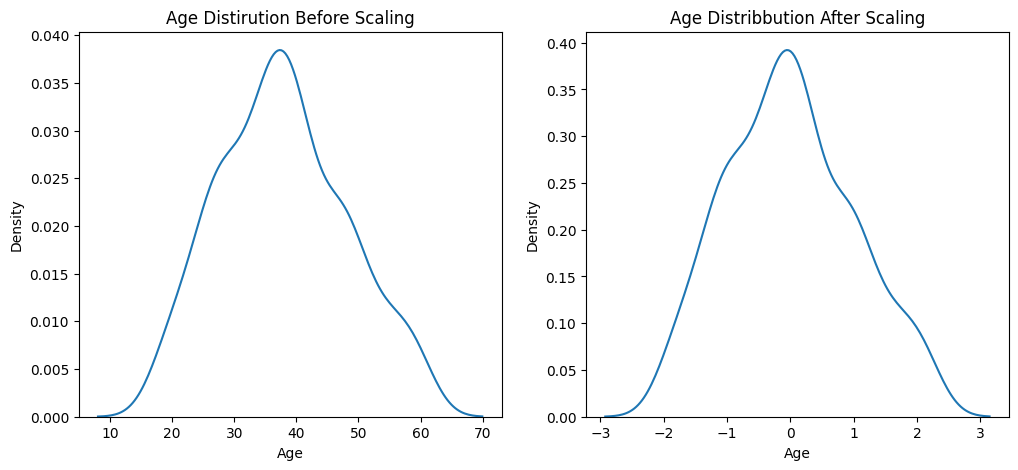

In [64]:
# Create a figure with two subplots side-by-side for Age distribution comparison
fig, ((ax1, ax2)) = plt.subplots(ncols = 2, figsize = (12, 5))

# Plot kernel density estimate (KDE) for 'Age' before scaling
ax1.set_title("Age Distirution Before Scaling") # Corrected typo 'Distirution' to 'Distribution'
sns.kdeplot(X_train['Age'], ax = ax1)

# Plot kernel density estimate (KDE) for 'Age' after scaling
ax2.set_title("Age Distribbution After Scaling") # Corrected typo 'Distribbution' to 'Distribution'
sns.kdeplot(X_train_scaled['Age'], ax = ax2)
plt.show() # Display the plot

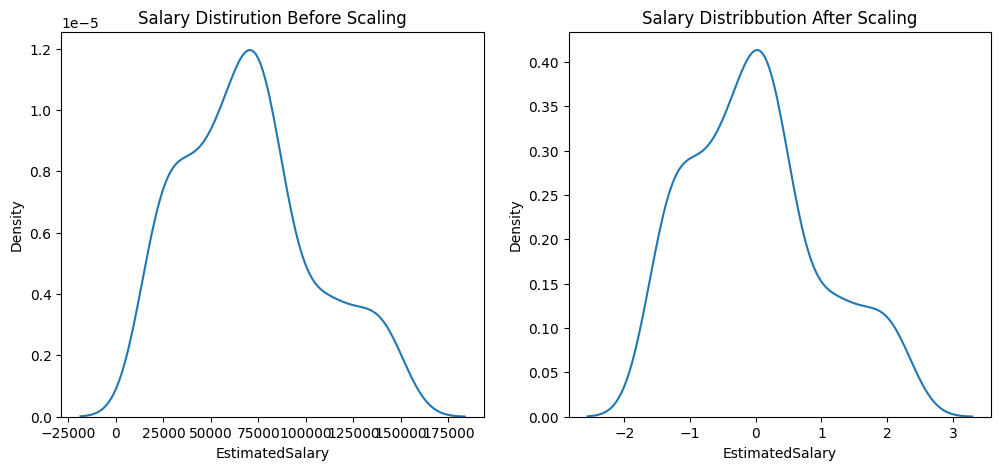

In [65]:
# Create a figure with two subplots side-by-side for EstimatedSalary distribution comparison
fig, ((ax1, ax2)) = plt.subplots(ncols = 2, figsize = (12, 5))

# Plot kernel density estimate (KDE) for 'EstimatedSalary' before scaling
ax1.set_title("Salary Distirution Before Scaling") # Corrected typo 'Distirution' to 'Distribution'
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

# Plot kernel density estimate (KDE) for 'EstimatedSalary' after scaling
ax2.set_title("Salary Distribbution After Scaling") # Corrected typo 'Distribbution' to 'Distribution'
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)
plt.show() # Display the plot

# Why Scaling is Important?

In [66]:
# Import LogisticRegression from sklearn for classification tasks
from sklearn.linear_model import LogisticRegression

In [67]:
# Initialize two Logistic Regression models:
# lr: for training on unscaled data
# lr_scaled: for training on scaled data
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [68]:
# Train the Logistic Regression model on the original (unscaled) training data
lr.fit(X_train, y_train)

# Train the Logistic Regression model on the scaled training data
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [69]:
# Make predictions on the unscaled test data using the model trained on unscaled data
y_pred = lr.predict(X_test)

# Make predictions on the scaled test data using the model trained on scaled data
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [70]:
# Import accuracy_score from sklearn.metrics to evaluate model performance
from sklearn.metrics import accuracy_score

In [71]:
# Print the accuracy score for the model trained on unscaled data
print("Actual", accuracy_score(y_test, y_pred))

# Print the accuracy score for the model trained on scaled data
# This comparison helps to understand the impact of scaling on model performance
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [72]:
# Import DecisionTreeClassifier for another classification task
from sklearn.tree import DecisionTreeClassifier

In [73]:
# Initialize two Decision Tree Classifier models:
# dt: for training on unscaled data
# dt_scaled: for training on scaled data
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [74]:
# Train the Decision Tree Classifier on the original (unscaled) training data
dt.fit(X_train, y_train)

# Train the Decision Tree Classifier on the scaled training data
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [75]:
# Make predictions on the unscaled test data using the model trained on unscaled data
y_pred = dt.predict(X_test)

# Make predictions on the scaled test data using the model trained on scaled data
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [76]:
# Print the accuracy score for the Decision Tree model trained on unscaled data
print("Actual", accuracy_score(y_test, y_pred))

# Print the accuracy score for the Decision Tree model trained on scaled data
# This comparison helps to understand if scaling benefits tree-based models (often less sensitive to scaling)
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [ ]:
# Display descriptive statistics for the entire DataFrame
# This provides a summary of central tendency, dispersion, and shape of the dataset's distribution
df.describe()

# Effect of Outlier

In [ ]:
# Concatenate the existing DataFrame with new data points containing potential outliers
# This simulates adding outliers to the dataset for further analysis of their effect
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [ ]:
# Create a scatter plot of 'Age' vs 'EstimatedSalary' for the DataFrame with added outliers
# This visualization helps to clearly see the newly introduced outlier points
plt.scatter(df['Age'], df['EstimatedSalary'])

In [ ]:
# Import the train_test_split function again
from sklearn.model_selection import train_test_split

# Split the updated DataFrame (with outliers) into training and testing sets
# This is a re-split after adding outliers, keeping the same test_size and random_state
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

# Print the shapes of the new training and testing feature sets
X_train.shape, X_test.shape

In [ ]:
# Import StandardScaler again
from sklearn.preprocessing import StandardScaler

# Initialize a new StandardScaler instance
scaler = StandardScaler()

# Fit the scaler to the new training data (which now includes any outliers if they ended up in the train set)
scaler.fit(X_train)

# Transform both the new training and testing data using the newly fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Convert the newly scaled NumPy arrays back into pandas DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
# Create a figure with two subplots side-by-side to visualize the effect of scaling on data with outliers
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Scatter plot of 'Age' vs 'EstimatedSalary' for the original training data (with potential outliers)
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# Scatter plot of 'Age' vs 'EstimatedSalary' for the scaled training data (with potential outliers)
# Notice how outliers can significantly influence the scaling and pull other points closer to the center
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show() # Display the plot